# Introduction to Sage: Symbolic Algebra and Calculus

[SageMath](https://www.sagemath.org) ("Sage") is a free, open-source computer algebra system built on Python.
It combines a number of established mathematics packages (Maxima for calculus, PARI, FLINT, Singular, and others)
behind one consistent interface, and it can also call NumPy, SciPy, Matplotlib and SymPy. For a physicist it fills
roughly the same role as Mathematica or Maple: deriving equations of motion, doing integrals and series expansions,
solving linear algebra problems exactly, and checking hand calculations.

Sage has its own extensive tutorial and help system, and your favorite AI likely knows a lot about this system to help you with specific problems. The Sage tutorial (3-4 hours to work through) is here: [Sage Tutorial](https://doc.sagemath.org/html/en/tutorial/index.html)

This notebook is a brief high level introduction. It covers:

1. Running Sage, and how Sage differs from plain Python
2. Exact and numerical arithmetic
3. Symbolic variables, expressions and functions
4. Simplification and substitution
5. Solving equations, exactly and numerically
6. Calculus: derivatives, integrals, limits, sums and series
7. Linear algebra: normal modes of coupled oscillators
8. Differential equations, symbolic and numerical
9. Equations of motion from a Lagrangian
10. Plotting
11. Moving results to NumPy, SymPy and LaTeX

If you have worked through `SY1_Sympy_introduction`, much of this will look familiar. SymPy is a Python
library that you import; Sage is a complete environment with a larger collection of algorithms, and in many cases
(integrals, differential equations, exact linear algebra) it is faster and more capable. See the `README.md` in this
folder for how to install or run Sage.

## 1. Running Sage

The best way to run this notebook is with the **SageMath** kernel. If you started Jupyter from your Sage installation
(`sage -n jupyter`), or selected the SageMath kernel in JupyterLab, everything is already set up.

The next cell only does some "magic" when the notebook runs on a plain Python kernel (for example in Google Colab, or in
PyCharm with the `sage` conda environment as interpreter). In that case it loads the Sage IPython extension, which
imports Sage and turns on the Sage *preparser* described below. In Colab it first installs Sage with pip,
which takes a few minutes. If Colab asks you to restart the session after the install, do so and run the cell again.

In [1]:
import sys
if "sage.all" not in sys.modules:            # plain Python kernel: switch Sage on
    if "google.colab" in sys.modules:
        %pip install -q passagemath-standard
    %load_ext sage.repl.ipython_extension

In [2]:
import sage.version
sage.version.version

'10.9'

### The preparser

Sage code is Python code, with a few changes made by a *preparser* before the code is run. The two that matter most:

* `^` means exponentiation (in Python, `^` is the bitwise XOR operator; `**` also still works).
* Integer literals become Sage integers, so `1/3` is an exact rational number, not the float `0.333...`.

You can see what the preparser does with `preparse()`:

In [3]:
preparse("f(x) = x^2 + 1/3")

'__tmp__=var("x"); f = symbolic_expression(x**Integer(2) + Integer(1)/Integer(3)).function(x)'

The symbol `x` is predefined as a symbolic variable. Every other symbolic variable must be declared before use (section 3).
Note that because of the preparser, a `.py` file containing Sage code will not run in plain Python. Files with Sage
syntax use the extension `.sage` and are run with `sage filename.sage`.

## 2. Exact and numerical arithmetic

Sage keeps numbers exact unless you ask for a numerical value.

In [4]:
1/3 + 1/6

1/2

In [5]:
sqrt(8), sqrt(8.0)

(2*sqrt(2), 2.82842712474619)

Once a floating point number appears in an expression, the result is numerical. To get a numerical value from an exact
expression, use `n()` (also written `N()` or `.numerical_approx()`). The precision can be chosen freely:

In [6]:
pi.n(), n(pi, digits=50)

(3.14159265358979, 3.1415926535897932384626433832795028841971693993751)

Note that unlike Python, in Sage, `i` is the complex number $\sqrt{-1}$, not a free to use integer. In Python you would use `1j`, and you would need to import numpy to get $\pi$. Note that mixing these two, the numpy and sage ways of computation, can give mixed results.

In [15]:
e^(i*pi), exp(1).n()

(-1, 2.71828182845905)

In [16]:
import numpy as np
print(np.exp( 1j * np.pi))
print(np.exp( 1j * pi))

(-1+1.2246467991473532e-16j)
e^(1.00000000000000*I*pi)


Sage also knows about integers, rationals, and number theory. As one example, here is the prime factorization of $2^{64}-1$:

In [17]:
factor(2^64 - 1)

3 * 5 * 17 * 257 * 641 * 65537 * 6700417

The type of an object tells you which set Sage thinks it belongs to: `ZZ` (integers), `QQ` (rationals), `RR` (real
floating point, 53 bits by default), `CC` (complex floating point), and `SR`, the *symbolic ring* of general expressions.

In [18]:
parent(3), parent(1/3), parent(0.5), parent(sqrt(2))

(Integer Ring,
 Rational Field,
 Real Field with 53 bits of precision,
 Symbolic Ring)

## 3. Symbolic variables, expressions and functions

Variables are declared with `var()`. The names in the string become Python variables in the notebook.

In [19]:
var('t omega A phi')
y = A*cos(omega*t + phi)
y

A*cos(omega*t + phi)

`show()` displays an expression typeset with LaTeX. (In a plain Python kernel it may print plain text instead; the results are the same.) If you want to add specific LaTex text to the output, add it with `LatexExpr()`. 

In [43]:
show(y)
show(LatexExpr('y(t) ='),y)

A*cos(omega*t + phi)

y(t) = A*cos(omega*t + phi)

An alternative way to get pretty ouput is to use HTML with the `html()` function. Super useful to get nice homework output!

In [55]:
show(html(f"The expression is $y(t) = {latex(y)}$"))

The expression is \(y(t) = A \cos\left(\omega t + \phi\right)\)

A *callable symbolic function* is defined with the notation `f(x) = ...`. It can be evaluated, differentiated and
integrated, and it knows which variable is its argument.

In [56]:
f(x) = x^3 - 2*x
show(f)
f

x |--> x^3 - 2*x

x |--> x^3 - 2*x

In [57]:
f(2), f(1/2), f(sqrt(2))

(4, -7/8, 0)

In [58]:
fp = diff(f, x)
fp, fp(1)

(x |--> 3*x^2 - 2, 1)

Greek letters and subscripts are typeset correctly if you name variables accordingly (`omega` -> $\omega$, `theta0` -> $\theta_0$, `x_1` -> $x_1$).
Python reserves the name `lambda`, so use `lambda_` or `lam` for $\lambda$ if you need it.

In [59]:
var('theta0','x_1')
show(theta0); show(x_1)

theta0

x_1

## 4. Simplification and substitution

Sage does not simplify automatically beyond trivial cases. You choose the transformation you want.

In [60]:
var('a b')
p = (a + b)^3
p.expand()

a^3 + 3*a^2*b + 3*a*b^2 + b^3

In [61]:
(x^2 - 1).factor()

(x + 1)*(x - 1)

In [62]:
r = (x^3 - 1)/(x^2 - 1)
show(r, LatexExpr(r'\rightarrow'))
show(r.simplify_rational())

(x^3 - 1)/(x^2 - 1) \rightarrow

(x^2 + x + 1)/(x + 1)

For trigonometric expressions, `trig_reduce()` rewrites powers and products as sums of multiple angles, and `trig_expand()`
does the reverse. `simplify_full()` applies a sequence of simplifications and is often a reasonable first thing to try.

In [63]:
show((sin(x)^3),'->')
show((sin(x)^3).trig_reduce())

sin(x)^3 '->'

-1/4*sin(3*x) + 3/4*sin(x)

In [64]:
sin(2*x + a).trig_expand()

cos(2*x)*sin(a) + cos(a)*sin(2*x)

In [65]:
(sin(x)^2 + cos(x)^2).simplify_full()

1

To test whether two expressions are equal, form the equation and convert it to a boolean. `bool()` returns `True` only
if Sage can prove the equality; `False` means "not proven", which is not always the same as "not equal".

In [66]:
bool(cos(2*x) == 1 - 2*sin(x)^2)

True

Substitution uses `subs()`. Either an equation or keyword arguments work:

In [67]:
y.subs(t == 0), y.subs(A=2, phi=0)

(A*cos(phi), 2*cos(omega*t))

### Assumptions

Many results depend on the sign or type of a variable. For example $\sqrt{x^2} = |x|$, which equals $x$ only for
$x \geq 0$. Sage lets you state such facts with `assume()`, list them with `assumptions()`, and remove them with `forget()`.

In [71]:
var('s')
sqrt(s^2).simplify_full()

sqrt(s^2)

In [72]:
assume(s > 0)
sqrt(s^2).simplify_full()

s

In [73]:
assumptions()

[s > 0]

In [74]:
forget()
assumptions()

[]

Assumptions are global: they stay in effect until you call `forget()`. Forgetting this is a common source of confusing
results when you re-run cells out of order.

## 5. Solving equations

`solve()` finds exact solutions of equations and systems of equations. Note that `==` makes an equation, while `=` is
assignment.

In [75]:
var('a b c')
solve(a*x^2 + b*x + c == 0, x)

[x == -1/2*(b + sqrt(b^2 - 4*a*c))/a, x == -1/2*(b - sqrt(b^2 - 4*a*c))/a]

In [76]:
var('u v')
solve([u + v == 3, u - v == 1], u, v)

[[u == 2, v == 1]]

Solutions come back as a list of equations. To use one, select it and take the right hand side with `.rhs()`, or ask for
a dictionary with `solution_dict=True`:

In [77]:
sols = solve(x^2 - 3*x + 2 == 0, x)
show(sols)
sols[0].rhs(), sols[1].rhs()

[x == 1, x == 2]

(1, 2)

In [78]:
solve(x^2 - 3*x + 2 == 0, x, solution_dict=True)

[{x: 1}, {x: 2}]

Transcendental equations usually have no closed form solution. `solve()` will then return the equation unchanged:

In [79]:
solve(tan(x) == x, x)

[x == tan(x)]

For these, use `find_root(f, a, b)`, which finds a numerical root of $f$ in the interval $[a, b]$. As an example, take
the even bound states of the finite square well (Griffiths, section 2.6). With $z = \ell\sqrt{2mE}/\hbar$ and
$z_0 = (\ell/\hbar)\sqrt{2mV_0}$, the allowed energies follow from
$$\tan z = \sqrt{(z_0/z)^2 - 1}.$$
For $z_0 = 8$, plot both sides to locate the crossings, then find each root in a bracket that contains exactly one of them:

findfont: Failed to find font weight medium for DejaVu Sans, now using 400.
findfont: Failed to find font weight medium for DejaVu Sans, now using 400.


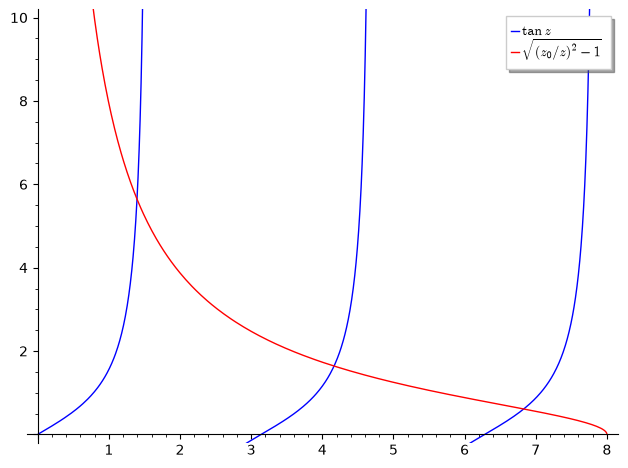

In [80]:
z = var('z')
z0 = 8
lhs = tan(z)
rhs = sqrt((z0/z)^2 - 1)
plot(lhs, (z, 0.01, z0), ymin=0, ymax=10, detect_poles=True, legend_label=r'$\tan z$') + \
    plot(rhs, (z, 0.01, z0), color='red', legend_label=r'$\sqrt{(z_0/z)^2-1}$')

In [81]:
roots = [find_root(lhs - rhs, a, b) for (a, b) in [(0.1, 1.5), (pi + 0.01, 3*pi/2 - 0.01), (2*pi + 0.01, 5*pi/2 - 0.01)]]
roots

[1.395466143871871, 4.164830914061048, 6.830674326203777]

The brackets avoid the poles of $\tan z$ at odd multiples of $\pi/2$, where $f$ changes sign without having a root.
`find_root()` needs a sign change, so choosing the interval is your job; the plot is how you do it.

## 6. Calculus

### Derivatives

In [85]:
var('t omega')
f(t) = sin(omega*t)*exp(-t)
show(f)
show(diff(f, t))

t |--> e^(-t)*sin(omega*t)

t |--> omega*cos(omega*t)*e^(-t) - e^(-t)*sin(omega*t)

Higher derivatives and partial derivatives:

In [86]:
show(diff(f, t, 3))

t |--> -omega^3*cos(omega*t)*e^(-t) + 3*omega^2*e^(-t)*sin(omega*t) + 3*omega*cos(omega*t)*e^(-t) - e^(-t)*sin(omega*t)

In [87]:
var('x y')
V = 1/sqrt(x^2 + y^2)
diff(V, x), diff(V, x, y)

(-x/(x^2 + y^2)^(3/2), 3*x*y/(x^2 + y^2)^(5/2))

The gradient of a function of several variables, here the force $\vec F = -\nabla V$ for a $1/r$ potential:

In [88]:
V(x, y) = 1/sqrt(x^2 + y^2)
-V.gradient()

(x, y) |--> (x/(x^2 + y^2)^(3/2), y/(x^2 + y^2)^(3/2))

### Integrals

`integrate(f, x)` gives an antiderivative (without the integration constant); `integrate(f, x, a, b)` a definite integral. Note the use of `oo` to indicate $\infty$

In [91]:
integrate(x^2*sin(x), x)

-(x^2 - 2)*cos(x) + 2*x*sin(x)

In [92]:
integrate(1/(1 + x^2), x, -oo, oo)

pi

When the answer depends on the sign of a parameter, Sage stops and asks. Here is the Gaussian integral
$\int_{-\infty}^{\infty} e^{-a x^2} dx$, which only converges for $a > 0$:

In [93]:
var('a')
try:
    integrate(exp(-a*x^2), x, -oo, oo)
except ValueError as err:
    print(err)

Computation failed since Maxima requested additional constraints; using the 'assume' command before evaluation *may* help (example of legal syntax is 'assume(a>0)', see `assume?` for more details)
Is a positive, negative or zero?


In [96]:
assume(a > 0)
show(integrate(exp(-a*x^2), x, -oo, oo))

sqrt(pi)/sqrt(a)

In [97]:
show(integrate(x^2*exp(-a*x^2), x, -oo, oo))

1/2*sqrt(pi)/a^(3/2)

In [98]:
forget()

Not every integral has a closed form. For those, `numerical_integral()` returns the value and an error estimate:

In [99]:
numerical_integral(sin(x)/x^(3/2), 1, 10)

(0.5995265769517781, 1.1302067318766655e-14)

### Limits and sums

In [100]:
limit(sin(x)/x, x=0), limit((1 + 1/x)^x, x=oo)

(1, e)

In [101]:
var('k')
sum(1/k^2, k, 1, oo), sum(k^2, k, 1, x).factor()

(1/6*pi^2, 1/6*(2*x + 1)*(x + 1)*x)

### Series expansions

`taylor(f, x, x0, n)` expands $f$ around $x_0$ to order $n$:

In [102]:
taylor(sqrt(1 + x), x, 0, 3)

1/16*x^3 - 1/8*x^2 + 1/2*x + 1

A physics example: the relativistic kinetic energy $T = (\gamma - 1) m c^2$ expanded for small $v/c$ gives the Newtonian
result plus corrections.

In [103]:
var('m c v')
T = (1/sqrt(1 - v^2/c^2) - 1)*m*c^2
T.taylor(v, 0, 6)

1/2*m*v^2 + 3/8*m*v^4/c^2 + 5/16*m*v^6/c^4

### Example: period of a pendulum at large amplitude

For a pendulum of length $l$ released from rest at angle $\theta_0$, energy conservation gives the exact period
$$T = 4\sqrt{\frac{l}{g}}\int_0^{\pi/2}\frac{d\phi}{\sqrt{1 - k^2\sin^2\phi}}, \qquad k = \sin(\theta_0/2).$$
The integral is the complete elliptic integral of the first kind, $K(k^2)$. Sage knows this function as `elliptic_kc(m)`,
with $m = k^2$. To find the correction to the small angle period $2\pi\sqrt{l/g}$, expand the integrand in $k$,
integrate term by term, then substitute $k = \sin(\theta_0/2)$ and expand in $\theta_0$:

In [125]:
var('k phi theta0 l g')
integrand = 1/sqrt(1 - k^2*sin(phi)^2)
# Note here the trick to get the equation correct. r"d\phi", the r makes sure the \ is not seen as an escape character, 
# and the Latex {} cannot appear inside an f" " (f-string)
show(html(r"The integration is $T= 4{\sqrt{\frac{l}{g}}\int_0^{\pi/2}}"f"{latex(integrand)}"r"d \phi$"))
series_k = integrand.taylor(k, 0, 4)
show(series_k)

The integration is \(T= 4{\sqrt{\frac{l}{g}}\int_0^{\pi/2}}\frac{1}{\sqrt{-k^{2} \sin\left(\phi\right)^{2} + 1}}d \phi\)

3/8*k^4*sin(phi)^4 + 1/2*k^2*sin(phi)^2 + 1

In [126]:
I_k = integrate(series_k, phi, 0, pi/2)
show(I_k)

1/2*pi + 9/128*pi*k^4 + 1/8*pi*k^2

In [127]:
T_series = (4*sqrt(l/g)*I_k.subs(k == sin(theta0/2))).taylor(theta0, 0, 4)
show(T_series)

11/1536*pi*theta0^4*sqrt(l/g) + 1/8*pi*theta0^2*sqrt(l/g) + 2*pi*sqrt(l/g)

Factoring out the small angle period makes the result easier to read:

In [128]:
show((T_series/(2*pi*sqrt(l/g))).expand())

11/3072*theta0^4 + 1/16*theta0^2 + 1

That is, $T \approx 2\pi\sqrt{l/g}\,\left(1 + \theta_0^2/16 + 11\theta_0^4/3072\right)$. A check at $\theta_0 = 60^\circ$
against the exact elliptic integral (in units where $\sqrt{l/g} = 1$):

In [129]:
th = pi/3
exact  = (4*elliptic_kc(sin(th/2)^2)).n()
approx = (T_series/sqrt(l/g)).subs(theta0=th).n()
small  = (2*pi).n()
exact, approx, small

(6.74300141925038, 6.74088417739078, 6.28318530717959)

## 7. Linear algebra: normal modes

Matrices can contain exact numbers or symbols. Consider two equal masses $m$ connected to each other and to two walls by
three equal springs $k$. With $\vec{x} = (x_1, x_2)$ the equations of motion are $M\ddot{\vec x} = -K\vec x$, and normal
modes $\vec x = \vec a\, e^{i\omega t}$ satisfy $M^{-1}K\,\vec a = \omega^2 \vec a$.

In [130]:
var('m k')
M = matrix([[m, 0], [0, m]])
K = matrix([[2*k, -k], [-k, 2*k]])
A = M.inverse()*K
A

[2*k/m  -k/m]
[ -k/m 2*k/m]

In [131]:
A.eigenvalues()

[k/m, 3*k/m]

`eigenvectors_right()` returns a list of triples: (eigenvalue, list of eigenvectors, multiplicity).

In [132]:
A.eigenvectors_right()

[(k/m, [(1, 1)], 1), (3*k/m, [(1, -1)], 1)]

So $\omega_1 = \sqrt{k/m}$ with the masses moving together, and $\omega_2 = \sqrt{3k/m}$ with the masses moving in
opposite directions. The usual matrix operations are all available:

In [133]:
K.det(), K.inverse(), K.transpose() == K

(
       [2/3/k 1/3/k]      
3*k^2, [1/3/k 2/3/k], True
)

When the matrix contains only numbers, say which ring it lives in: `QQ` for exact rationals, `RDF` for double precision
floating point (fast, using NumPy and SciPy underneath), `CDF` for complex doubles.

In [134]:
B = matrix(RDF, [[2, -1, 0], [-1, 2, -1], [0, -1, 2]])
B.eigenvalues()

[3.4142135623730914, 1.9999999999999993, 0.5857864376269047]

## 8. Differential equations

### Symbolic solutions

An unknown function is declared with `function()`. Here is the damped harmonic oscillator
$\ddot x + 2\gamma\dot x + \omega_0^2 x = 0$:

In [135]:
var('t gamma omega0')
x = function('x')(t)
eom = diff(x, t, 2) + 2*gamma*diff(x, t) + omega0^2*x == 0
eom

omega0^2*x(t) + 2*gamma*diff(x(t), t) + diff(x(t), t, t) == 0

The form of the solution depends on whether the oscillator is under-, critically, or over-damped, so Maxima asks:

In [136]:
try:
    desolve(eom, x, ivar=t)
except TypeError as err:
    print(err)

Computation failed since Maxima requested additional constraints; using the 'assume' command before evaluation *may* help (example of legal syntax is 'assume((omega0-gamma)*(omega0+gamma)
>0)', see `assume?` for more details)
Is (omega0-gamma)*(omega0+gamma)
    positive, negative or zero?


For the underdamped case, assume $\omega_0 > \gamma > 0$. The initial conditions are given as `ics=[t0, x(t0), x'(t0)]`:

In [137]:
assume(omega0 > gamma, gamma > 0)
sol = desolve(eom, x, ivar=t, ics=[0, 1, 0])
sol

-1/2*(sqrt(-4*gamma^2 + 4*omega0^2)*gamma*sin(1/2*sqrt(-4*gamma^2 + 4*omega0^2)*t)/(gamma^2 - omega0^2) - 2*cos(1/2*sqrt(-4*gamma^2 + 4*omega0^2)*t))*e^(-gamma*t)

This is correct but not in the form you would write by hand. Introducing the damped frequency
$\omega_d = \sqrt{\omega_0^2 - \gamma^2}$ cleans it up:

In [138]:
forget()
var('omega_d')
assume(omega_d > 0, gamma > 0)
sol_d = sol.subs(omega0 == sqrt(gamma^2 + omega_d^2)).simplify_full()
sol_d

(omega_d*cos(omega_d*t) + gamma*sin(omega_d*t))*e^(-gamma*t)/omega_d

It is good practice to verify a solution by substituting it back:

In [139]:
check = diff(sol_d, t, 2) + 2*gamma*diff(sol_d, t) + (gamma^2 + omega_d^2)*sol_d
check.simplify_full(), sol_d.subs(t=0), diff(sol_d, t).subs(t=0).simplify_full()

(0, 1, 0)

In [140]:
forget()

### Numerical solutions

Most nonlinear equations have no closed form solution. `desolve_odeint()` integrates a first order system numerically
(it calls SciPy's `odeint`). Write the pendulum $\ddot\theta = -(g/l)\sin\theta$ as two first order equations,
$\dot\theta = \omega$, $\dot\omega = -\sin\theta$, in units where $g/l = 1$:

In [141]:
var('th w t')
times = srange(0, 20, 0.05)
theta_start = 0.99*pi/2                      # released from rest at about 89 degrees
num = desolve_odeint([w, -sin(th)], ics=[theta_start, 0], times=times, dvars=[th, w], ivar=t)
num.shape

(400, 2)

The result is a NumPy array with one row per time and one column per variable. Compare with the small angle solution:

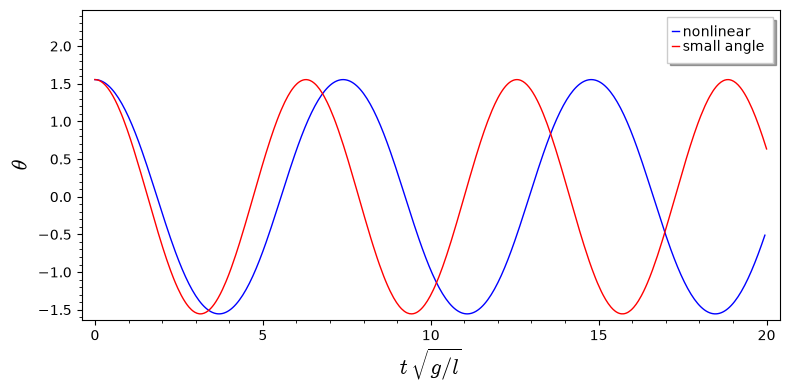

In [142]:
p = list_plot(list(zip(times, num[:, 0])), plotjoined=True, legend_label='nonlinear')
p += plot(theta_start*cos(t), (t, 0, 20), color='red', legend_label='small angle')
p.set_legend_options(loc='upper right')
p.show(frame=True, axes=False, ymax=2.4, axes_labels=[r'$t\,\sqrt{g/l}$', r'$\theta$'], figsize=[8, 4])

The large amplitude pendulum has a longer period, as the elliptic integral in section 6 predicted.

## 9. Equations of motion from a Lagrangian

Deriving the Euler-Lagrange equations
$$\frac{d}{dt}\frac{\partial L}{\partial \dot q} - \frac{\partial L}{\partial q} = 0$$
is a natural job for a computer algebra system. Sage cannot directly differentiate with respect to $\dot\theta(t)$, so
the standard approach is: write $L$ in terms of plain symbols $q$ and $\dot q$ (here `qdot`), take the partial
derivatives, and only then substitute the actual path $q \to \theta(t)$, $\dot q \to \dot\theta(t)$.

For the simple pendulum, $L = \frac12 m l^2\dot\theta^2 + m g l\cos\theta$:

In [143]:
var('t m l g q qdot')
L = 1/2*m*l^2*qdot^2 + m*g*l*cos(q)

theta = function('theta')(t)
on_path = {q: theta, qdot: diff(theta, t)}

EL = diff(L.diff(qdot).subs(on_path), t) - L.diff(q).subs(on_path) == 0
EL

g*l*m*sin(theta(t)) + l^2*m*diff(theta(t), t, t) == 0

In [144]:
solve(EL, diff(theta, t, 2))

[diff(theta(t), t, t) == -g*sin(theta(t))/l]

The same few lines work for any Lagrangian. Below is a small function that does this for a system with several
coordinates. It takes the Lagrangian, a list of coordinate symbols, a list of velocity symbols, and the time variable,
and returns the list of equations of motion. `trig_reduce()` at the end combines products such as
$\cos\theta_1\cos\theta_2 + \sin\theta_1\sin\theta_2$ into $\cos(\theta_1 - \theta_2)$.

In [145]:
def euler_lagrange(L, coords, velocities, t):
    paths = [function(str(q))(t) for q in coords]
    on_path = {}
    for q, qd, path in zip(coords, velocities, paths):
        on_path[q] = path
        on_path[qd] = diff(path, t)
    return [(diff(L.diff(qd).subs(on_path), t) - L.diff(q).subs(on_path)).simplify_full().trig_reduce() == 0
            for q, qd in zip(coords, velocities)]

As a test, the planar double pendulum (two equal lengths $l$ and equal masses $m$, see also `Notebooks/A02_Double_Pendulum`).
With angles $\theta_1, \theta_2$ measured from the vertical:

In [146]:
var('t1 t2 t1d t2d')
x1, y1 = l*sin(t1), -l*cos(t1)
x2, y2 = x1 + l*sin(t2), y1 - l*cos(t2)

# velocities by the chain rule, written out in terms of the velocity symbols
def velocity(expr):
    return expr.diff(t1)*t1d + expr.diff(t2)*t2d

T = 1/2*m*(velocity(x1)^2 + velocity(y1)^2) + 1/2*m*(velocity(x2)^2 + velocity(y2)^2)
U = m*g*y1 + m*g*y2
L2 = (T - U).simplify_full().trig_reduce()
L2

l^2*m*t1d*t2d*cos(-t1 + t2) + l^2*m*t1d^2 + 1/2*l^2*m*t2d^2 + 2*g*l*m*cos(t1) + g*l*m*cos(t2)

In [147]:
eqs = euler_lagrange(L2, [t1, t2], [t1d, t2d], t)
for eq in eqs:
    show((eq/(m*l^2)).expand())

-sin(-t1(t) + t2(t))*diff(t2(t), t)^2 + cos(-t1(t) + t2(t))*diff(t2(t), t, t) + 2*g*sin(t1(t))/l + 2*diff(t1(t), t, t) == 0

sin(-t1(t) + t2(t))*diff(t1(t), t)^2 + cos(-t1(t) + t2(t))*diff(t1(t), t, t) + g*sin(t2(t))/l + diff(t2(t), t, t) == 0

## 10. Plotting

Sage has its own plotting commands, built on Matplotlib. Plots are objects: you add them with `+`, and show or save them.

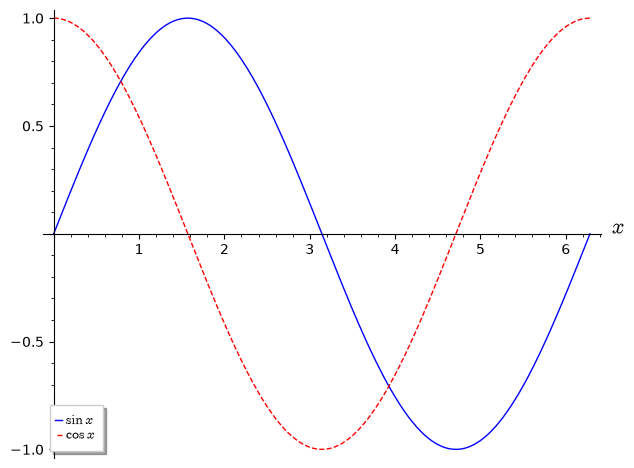

In [148]:
var('x')                   # x was redefined as a function in section 8
P = plot(sin(x), (x, 0, 2*pi), legend_label=r'$\sin x$')
P += plot(cos(x), (x, 0, 2*pi), color='red', linestyle='--', legend_label=r'$\cos x$')
P.axes_labels(['$x$', ''])
P

Some other plot types: parametric curves, contour plots of functions of two variables, and vector fields. The example
below shows the phase space of the pendulum: contours of constant energy $E = \frac12\omega^2 - \cos\theta$ together
with the flow $(\dot\theta, \dot\omega) = (\omega, -\sin\theta)$.

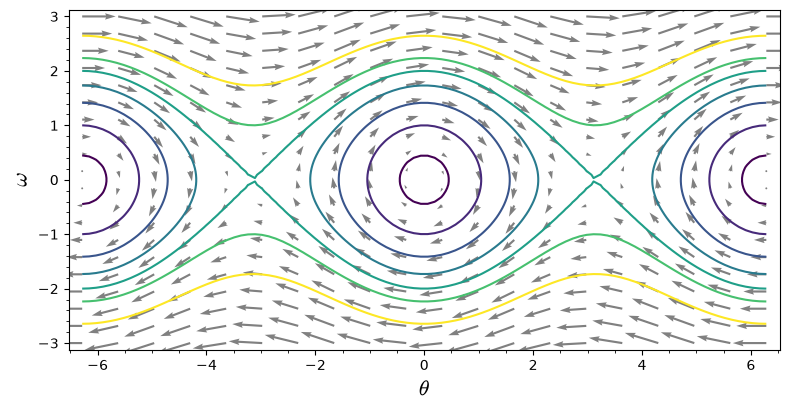

In [149]:
var('th w')
E = 1/2*w^2 - cos(th)
cp = contour_plot(E, (th, -2*pi, 2*pi), (w, -3, 3), contours=[-0.9, -0.5, 0, 0.5, 1, 1.5, 2.5],
                  fill=False, cmap='viridis', aspect_ratio=1)
vf = plot_vector_field((w, -sin(th)), (th, -2*pi, 2*pi), (w, -3, 3), color='gray')
(cp + vf).show(axes_labels=[r'$\theta$', r'$\omega$'], figsize=8)

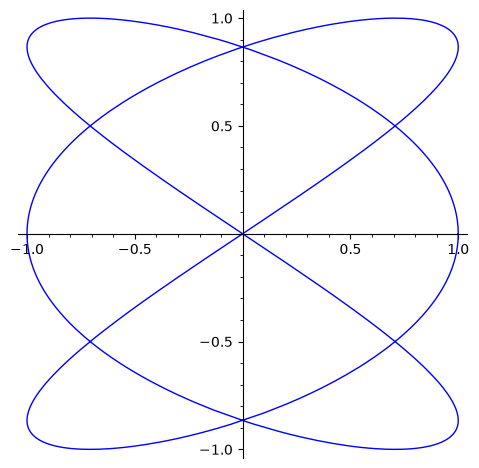

In [150]:
var('t')
parametric_plot((cos(3*t), sin(2*t)), (t, 0, 2*pi), aspect_ratio=1)   # a Lissajous figure

`plot3d()` makes interactive 3D plots in a browser based Jupyter. In some environments (PyCharm, for example) the
interactive viewer does not display; adding `viewer='tachyon'` to `show()` gives a static image instead.

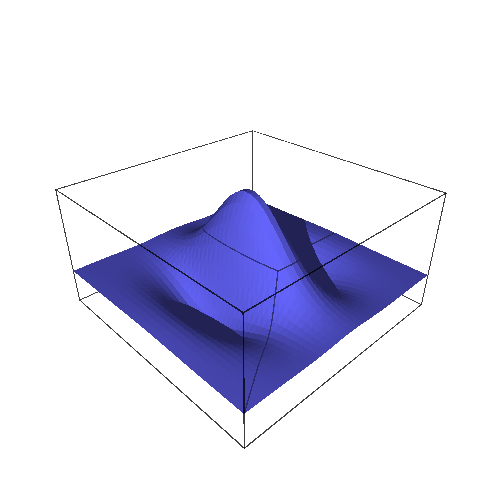

In [151]:
var('x y')
plot3d(exp(-(x^2 + y^2))*cos(3*x), (x, -2, 2), (y, -2, 2)).show(viewer='tachyon')

Use `P.save('figure.pdf')` (or `.png`) to write a plot to a file.

## 11. Using results elsewhere

A typical workflow is to derive an expression symbolically, then evaluate it many times numerically. There are a few
ways to move a Sage result into the rest of your Python work.

**Fast numerical function.** `fast_callable()` compiles an expression into a function of floats:

In [152]:
var('x')
expr = exp(-x^2/2)*cos(3*x)
f_num = fast_callable(expr, vars=[x], domain=float)
f_num(0.5)

0.06242536136924969

**NumPy, via SymPy.** Every Sage expression can be converted to SymPy, and SymPy's `lambdify` makes a function that works
on NumPy arrays:

In [153]:
import numpy as np
import sympy

expr_sympy = expr._sympy_()
f_np = sympy.lambdify(sympy.Symbol('x'), expr_sympy, 'numpy')
f_np(np.linspace(0, 1, 5))

array([ 1.        ,  0.70917717,  0.06242536, -0.47417033, -0.6004608 ])

Going back from SymPy to Sage is done with `SR()`:

In [154]:
SR(expr_sympy)

cos(3*x)*e^(-1/2*x^2)

**LaTeX.** `latex()` gives the LaTeX source of any expression, ready to paste into a report:

In [155]:
print(latex(T_series))

\frac{11}{1536} \, \pi \theta_{0}^{4} \sqrt{\frac{l}{g}} + \frac{1}{8} \, \pi \theta_{0}^{2} \sqrt{\frac{l}{g}} + 2 \, \pi \sqrt{\frac{l}{g}}


## 12. Getting help

* Put `?` after a function name to see its documentation and examples, e.g. `desolve?`. Two question marks (`desolve??`)
  show the source code.
* Press Tab after a `.` to see the methods an object has, e.g. `sol_d.` then Tab.
* The [Sage tutorial](https://doc.sagemath.org/html/en/tutorial/index.html) and the
  [reference manual](https://doc.sagemath.org/html/en/reference/index.html).
* *Computational Mathematics with SageMath* by Zimmermann et al. is a full textbook, free to download from
  the Sage website.

In [156]:
find_root?

Signature:     
find_root(
    f,
    a,
    b,
    xtol=1e-12,
    rtol=8.881784197001252e-16,
    maxiter=100,
    full_output=False,
)
Docstring:     
so doctests may not pass.

Numerically find a root of "f" on the closed interval [a,b] (or [b,a])
if possible, where "f" is a function in the one variable. Note: this
function only works in fixed (machine) precision, it is not possible
to get arbitrary precision approximations with it.

INPUT:

* "f" -- a function of one variable or symbolic equality

* "a", "b" -- endpoints of the interval

* "xtol", "rtol" -- the routine converges when a root is known to lie
  within "xtol" of the value return. Should be >= 0. The routine
  modifies this to take into account the relative precision of
  doubles. By default, rtol is "4*numpy.finfo(float).eps", the minimum
  allowed value for "scipy:scipy.optimize.brentq()", which is what
  this method uses underneath. This value is equal to "2.0**-50" for
  IEEE-754 double precision floats as used by 

## Exercises

1. **Overdamping.** Solve the damped oscillator of section 8 for the overdamped case $\gamma > \omega_0 > 0$ with
   $x(0) = 1$, $\dot x(0) = 0$. Plot the under-, critically, and overdamped solutions on one graph for $\omega_0 = 1$.
   (For critical damping, substitute $\gamma = \omega_0$ in the equation before solving.)

2. **Bead on a rotating hoop.** A bead of mass $m$ slides without friction on a hoop of radius $R$ that rotates with
   constant angular velocity $\Omega$ about a vertical diameter. With $\theta$ measured from the bottom,
   $L = \frac12 m R^2(\dot\theta^2 + \Omega^2\sin^2\theta) + m g R\cos\theta$.
   Use `euler_lagrange()` to find the equation of motion. Then use `solve()` to find the equilibrium angles, and show
   that the equilibrium at $\theta = 0$ becomes unstable for $\Omega^2 > g/R$. Compare with
   `Notebooks/A01b_Pendulum_Bead_on_Loop`.

3. **Three coupled masses.** Extend the normal mode calculation of section 7 to three equal masses between two walls,
   connected by four equal springs. Find the three frequencies and describe the mode shapes.

4. **Finite square well.** Repeat the root finding of section 5 for $z_0 = 4$. How many even bound states are there?
   The odd states satisfy $-\cot z = \sqrt{(z_0/z)^2 - 1}$; find those too. Compare with `QM_Notebooks/QM4_Finite_Square_Well_Solutions`.

5. **Checking a homework problem.** Take an integral, series expansion, or differential equation from one of your
   current physics courses and solve it with Sage. Then verify the result independently: by differentiating, by
   substituting back, or by comparing with a numerical calculation.